In [132]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 


In [133]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [134]:
# Load the dataset
file_path = 'C:\\Users\\zalew\\OneDrive\\Desktop\\Projects\\Feature-Engineering-Building-ML-Pipeline-\\data\\car_price_dataset_public.csv'
df = pd.read_csv(file_path)

# Display basic information about dataset shape
shape_of_df = df.shape
print(f"Dataset shape: {shape_of_df[0]} rows × {shape_of_df[1]} columns")
shape_of_df

Dataset shape: 1800 rows × 11 columns


(1800, 11)

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        1800 non-null   int64  
 1   Brand         1800 non-null   str    
 2   Model_Year    1480 non-null   float64
 3   Engine_Size   1480 non-null   str    
 4   Fuel_Type     1800 non-null   str    
 5   Transmission  1800 non-null   str    
 6   Mileage       1487 non-null   float64
 7   Doors         1480 non-null   float64
 8   Owner_Count   1480 non-null   float64
 9   Horsepower    1491 non-null   float64
 10  Price         1800 non-null   float64
dtypes: float64(6), int64(1), str(4)
memory usage: 154.8 KB


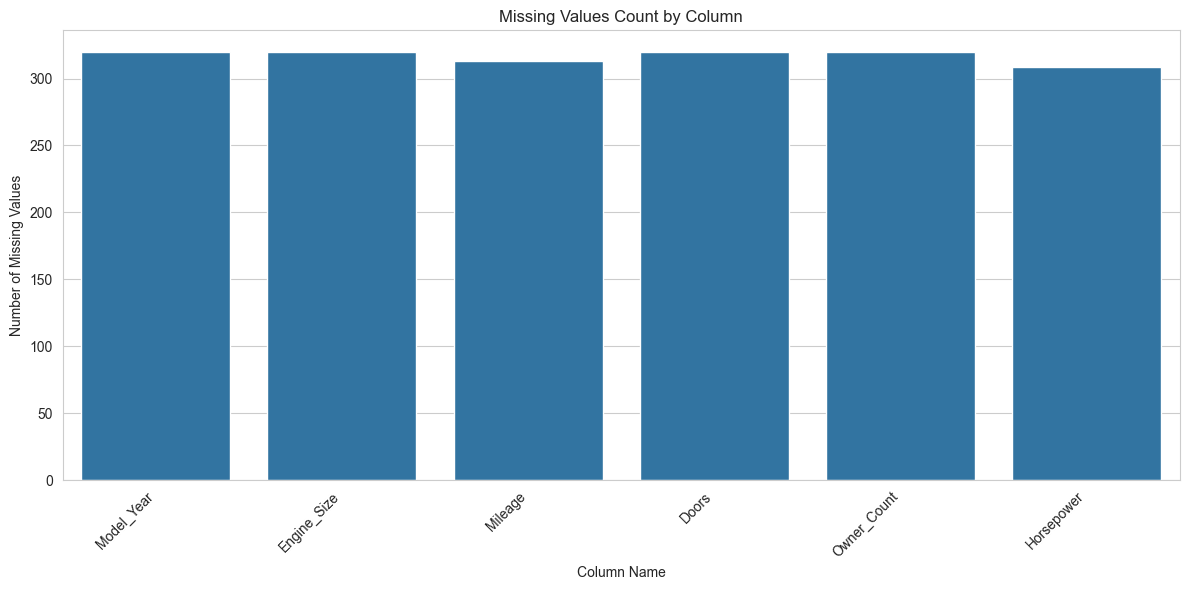

In [136]:
column_names = list(df.columns)
missing_val_count=df.isna().sum()
missing_val_df=pd.DataFrame({
        'column_name': column_names,
     'missing_values': missing_val_count,
     "missing %": (missing_val_count / len(df) * 100).round(2)
})
missing_val_df_filtered = missing_val_df[missing_val_df["missing_values"] > 0]

if len(missing_val_df_filtered) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='column_name', y='missing_values', data=missing_val_df_filtered)
    plt.title('Missing Values Count by Column')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset")



In [137]:
numerical_cols =df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")



Numerical columns: ['Car_ID', 'Model_Year', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price']


In [138]:
caterogical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {caterogical_cols}")

Categorical columns: ['Brand', 'Engine_Size', 'Fuel_Type', 'Transmission']


C:\Users\zalew\AppData\Local\Temp\ipykernel_27664\213373653.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  caterogical_cols = df.select_dtypes(include=['object']).columns.tolist()


ID Analysis


In [139]:
print("sample IDs:")
print(df["Car_ID"].head(10))

sample IDs:
0     969
1     241
2     820
3     693
4     421
5    1086
6    1999
7     366
8    1023
9    1241
Name: Car_ID, dtype: int64


In [140]:
#chcek for duplicated IDs

duplicate_count  = df["Car_ID"].value_counts()
duplicates_with_multiple_entries = duplicate_count[duplicate_count > 1]
print(f"Number of duplicate Car_IDs: {len(duplicates_with_multiple_entries)}")
print(duplicates_with_multiple_entries.head(20))


Number of duplicate Car_IDs: 200
Car_ID
594     2
1327    2
427     2
1294    2
1494    2
1259    2
1358    2
484     2
272     2
940     2
932     2
446     2
681     2
695     2
1161    2
1652    2
722     2
734     2
1980    2
1207    2
Name: count, dtype: int64


In [141]:
duplicated_ids = df[df.duplicated(subset=['Car_ID'], keep=False)]
print(f"Number of duplicated rows based on Car_ID: {len(duplicated_ids)}")
print(list(duplicated_ids["Car_ID"].head(20)))

Number of duplicated rows based on Car_ID: 400
[594, 1327, 427, 1294, 1494, 1259, 1358, 484, 272, 940, 932, 446, 681, 695, 1161, 1652, 722, 734, 1980, 1207]


In [142]:
unequal_ids =[]

for id in set(duplicated_ids):
    df_IDs= df[df["Car_ID"] == id]
    for lable in df.columns:
        unique_vlaue_count = len(df_IDs[lable].value_counts())
        if unique_vlaue_count >1:
            unequal_ids.append((id, lable))
            break
if unequal_ids:
    print(f"Found {len(unequal_ids)} column variations in duplicate records:")
    print(unequal_ids)
else:
    print("No variations found - all duplicate records have identical values")

No variations found - all duplicate records have identical values


In [143]:
# drop duplicated records 
df= df.drop_duplicates(subset=['Car_ID'], keep='first').reset_index(drop=True)
print(f"Dataset shape after dropping duplicates: {df.shape}")

Dataset shape after dropping duplicates: (1600, 11)


In [144]:
#split dataet into train and test sets 
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Training set shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")


Training set shape: (1280, 11)
Testing set shape: (320, 11)


In [145]:
# model_Years analysis
print(df_train['Model_Year'].describe())

print(df_train['Model_Year'].unique())


count    1022.000000
mean     1718.497065
std       710.566414
min         5.000000
25%      2007.000000
50%      2012.500000
75%      2018.000000
max      2023.000000
Name: Model_Year, dtype: float64
[  nan 2017. 2015. 2012. 2022. 2013. 2008. 2016. 2014. 2023. 2018.   12.
 2011. 2021. 2020. 2006. 2005. 2019.   10. 2010.    7.   20.    9.    5.
 2007.   16.    6.    8. 2009.   17.   11.   19.   22.   14.   18.   15.
   13.   21.   23.]


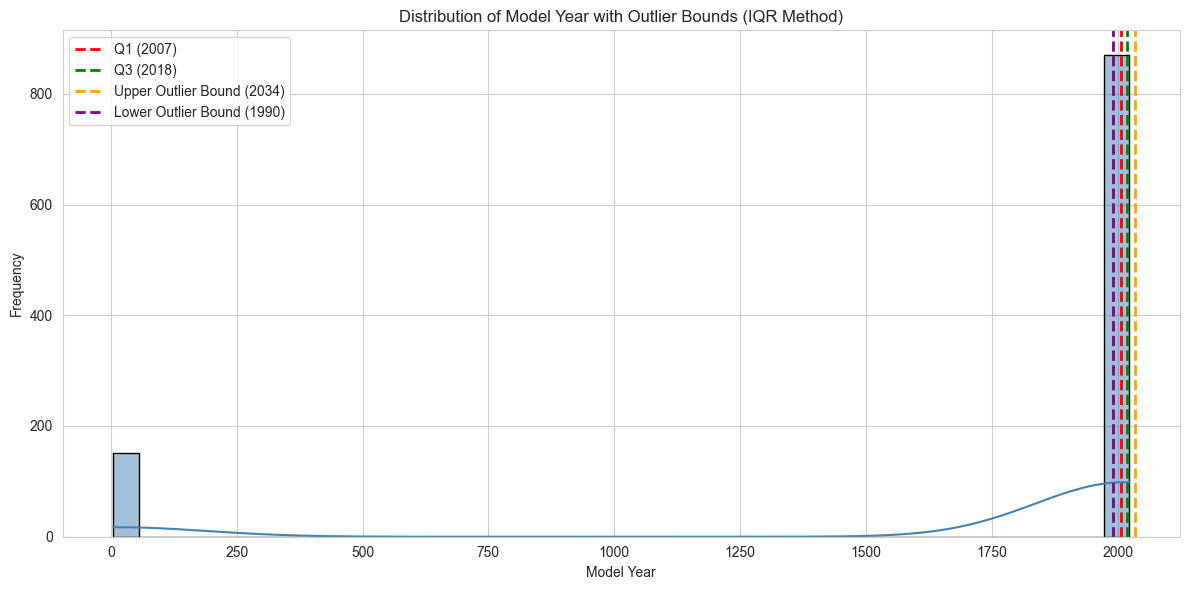

Model Year - Q1: 2007.0, Q3: 2018.0, IQR: 11.0, Upper Bound: 2034.5, Lower Bound: 1990.5


In [146]:
Q1 = df_train['Model_Year'].quantile(0.25)
Q3 = df_train['Model_Year'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df_train['Model_Year'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Model Year with Outlier Bounds (IQR Method)')
plt.xlabel('Model Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Model Year - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

Mileage analysis

In [147]:
print(df_train['Mileage'].describe())

count      1018.000000
mean     124171.235756
std      152451.930733
min        5036.000000
25%       54790.750000
50%      105458.500000
75%      150716.750000
max      999999.000000
Name: Mileage, dtype: float64


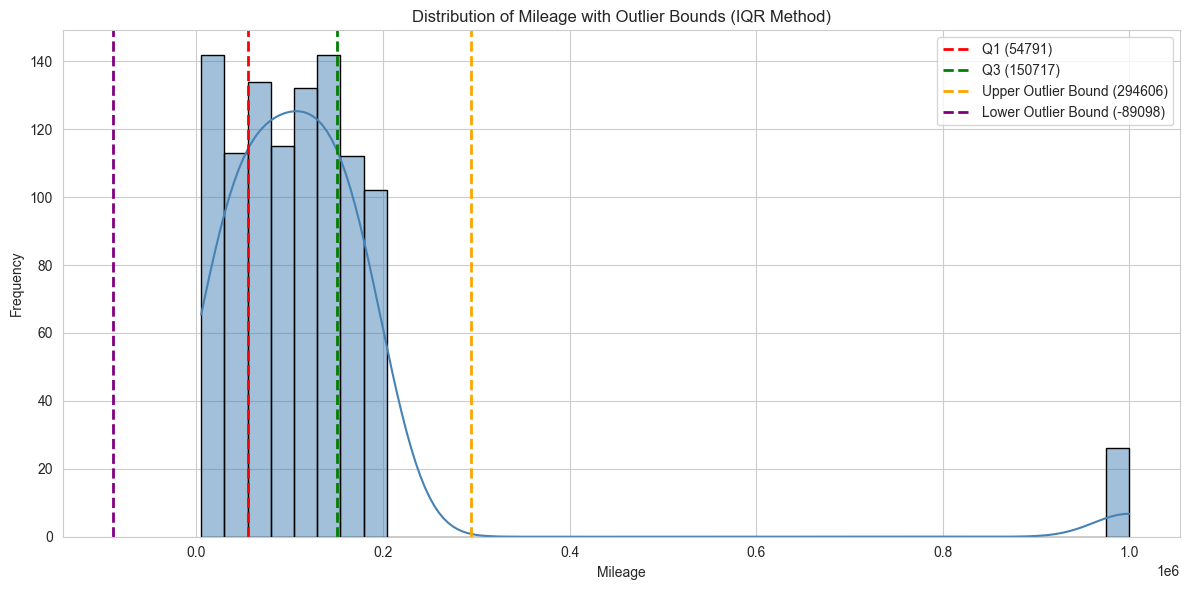

Mileage - Q1: 54790.75, Q3: 150716.75, IQR: 95926.0, Upper Bound: 294605.75, Lower Bound: -89098.25


In [148]:
Q1 = df_train['Mileage'].quantile(0.25)
Q3 = df_train['Mileage'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df_train['Mileage'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Mileage with Outlier Bounds (IQR Method)')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mileage - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

Doors analysis

In [149]:
print(df_train['Doors'].describe())

count    1025.000000
mean        2.987317
std         0.822555
min         2.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Doors, dtype: float64


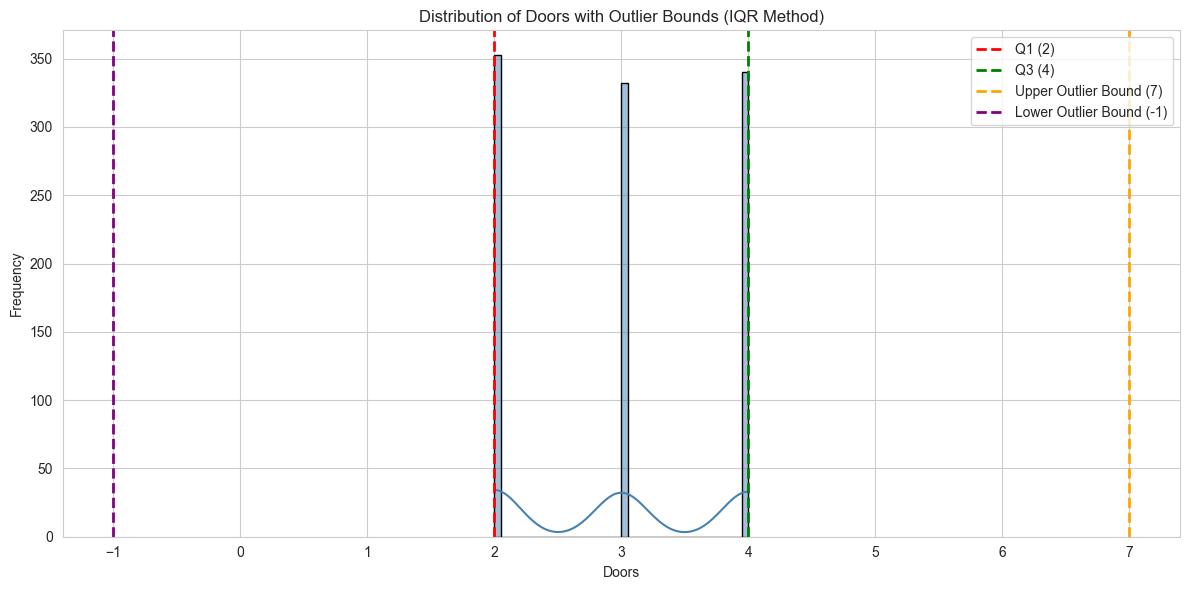

Doors - Q1: 2.0, Q3: 4.0, IQR: 2.0, Upper Bound: 7.0, Lower Bound: -1.0


In [150]:
Q1 = df_train['Doors'].quantile(0.25)
Q3 = df_train['Doors'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df_train['Doors'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Doors with Outlier Bounds (IQR Method)')
plt.xlabel('Doors')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Doors - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

Owner_Count analysis 

In [151]:
print(df_train['Owner_Count'].describe())

count    1016.000000
mean        2.521654
std         1.134989
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Owner_Count, dtype: float64


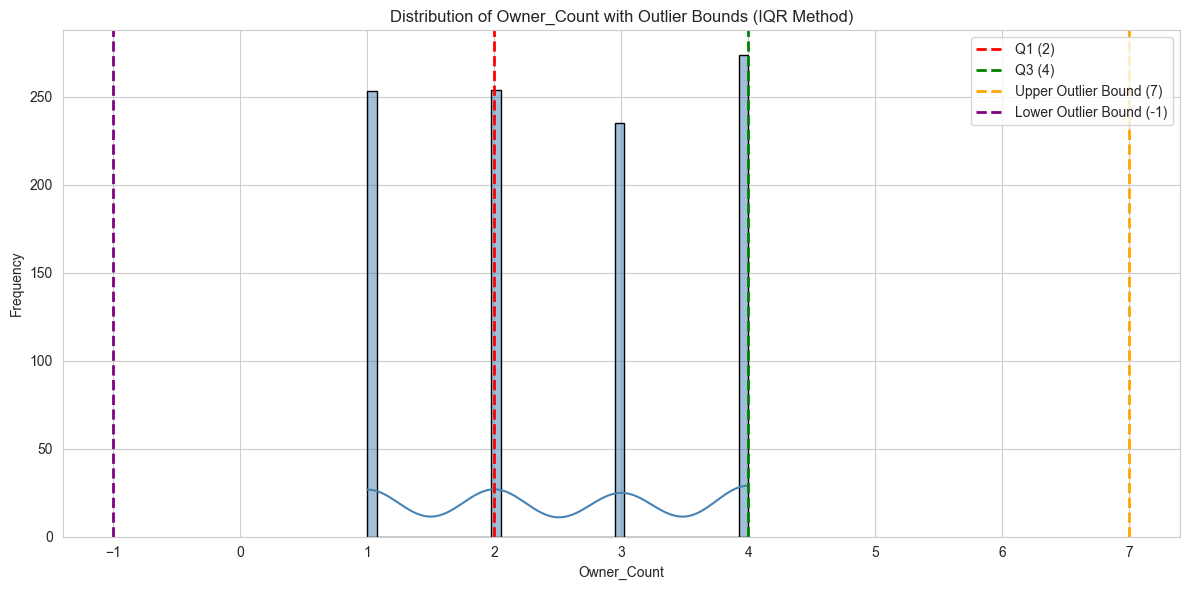

Owner_Count - Q1: 2.0, Q3: 4.0, IQR: 2.0, Upper Bound: 7.0, Lower Bound: -1.0


In [152]:
Q1 = df_train['Owner_Count'].quantile(0.25)
Q3 = df_train['Owner_Count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df_train['Owner_Count'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Owner_Count with Outlier Bounds (IQR Method)')
plt.xlabel('Owner_Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Owner_Count - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

Horsepower analysis

In [153]:
print(df_train['Horsepower'].describe())

count    1024.000000
mean      363.433594
std       783.463381
min        70.000000
25%       154.000000
50%       240.000000
75%       325.250000
max      5000.000000
Name: Horsepower, dtype: float64


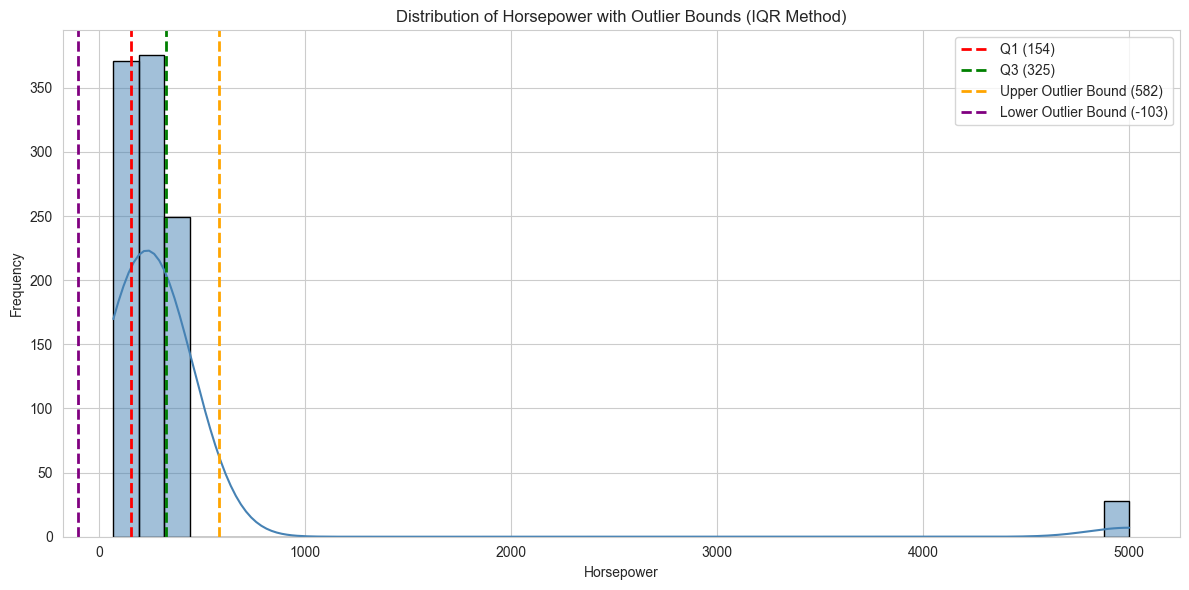

Horsepower - Q1: 154.0, Q3: 325.25, IQR: 171.25, Upper Bound: 582.125, Lower Bound: -102.875


In [154]:
Q1 = df_train['Horsepower'].quantile(0.25)
Q3 = df_train['Horsepower'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df_train['Horsepower'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Horsepower with Outlier Bounds (IQR Method)')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Horsepower - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

Price analysis


In [155]:
print(df_train['Price'].describe())
print(df_train['Price'].value_counts())

count     1280.000000
mean     43486.379336
std      14440.763381
min     -10000.000000
25%      38719.850000
50%      45343.850000
75%      52044.912500
max      69079.300000
Name: Price, dtype: float64
Price
-10000.00    38
 0.00        25
 61395.45     1
 49188.90     1
 47151.75     1
             ..
 32714.75     1
 33014.60     1
 50202.20     1
 60679.50     1
 44325.45     1
Name: count, Length: 1219, dtype: int64


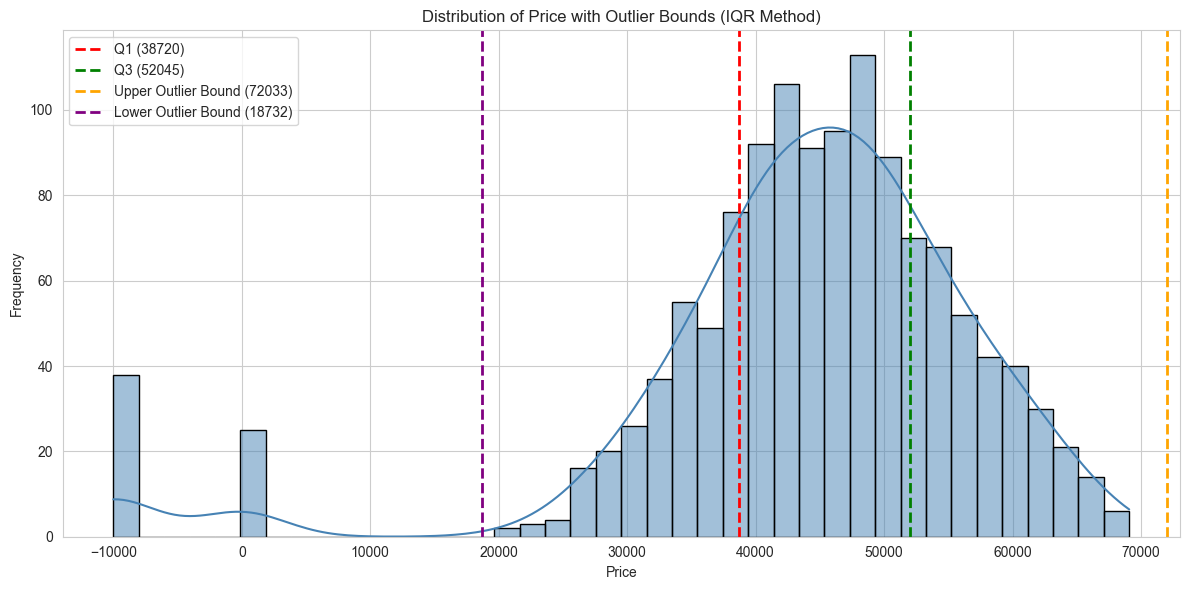

Price - Q1: 38719.85, Q3: 52044.912500000006, IQR: 13325.062500000007, Upper Bound: 72032.50625000002, Lower Bound: 18732.256249999988


In [156]:
Q1 = df_train['Price'].quantile(0.25)
Q3 = df_train['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df_train['Price'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Price with Outlier Bounds (IQR Method)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Price - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

Categorical Features Analysis

Brand analysis

count     1280
unique       6
top        BMW
freq       234
Name: Brand, dtype: object 

Brand
BMW        234
Honda      219
Hyundai    213
Toyota     211
Ford       203
Tesla      200
Name: count, dtype: int64


C:\Users\zalew\AppData\Local\Temp\ipykernel_27664\2269987620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Brand', data=df_train, order=df_train['Brand'].value_counts().index, palette='viridis')


Text(0.5, 1.0, 'Distribution of Car Brands')

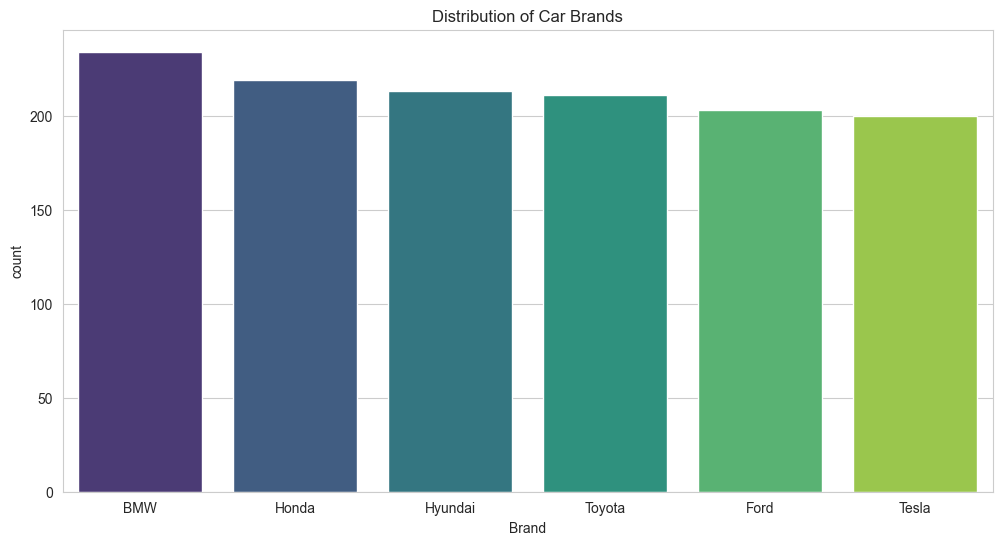

In [157]:
print(f'{df_train['Brand'].describe()} \n')


print(df_train['Brand'].value_counts())

sns.countplot(x='Brand', data=df_train, order=df_train['Brand'].value_counts().index, palette='viridis')
plt.title('Distribution of Car Brands')

Engine_Size analysis

count     1019
unique      81
top        2.6
freq        36
Name: Engine_Size, dtype: object 

<StringArray>
['4100 cc',     '1.4',     '3.6',       nan,     '3.9',     '2.7', '1400 cc',
 '3700 cc',     '4.7',     '2.2',     '1.2', '3200 cc',     '1.3',     '3.8',
 '3000 cc',     '3.4',     '3.2', '4600 cc',     '1.8',     '2.6',     '4.9',
 '4200 cc',     '3.0',     '2.1',     '1.6', '2400 cc', '1900 cc',     '4.3',
     '5.0',     '2.3',     '1.9', '4000 cc',     '2.4',     '1.7', '2300 cc',
 '3300 cc',     '3.5',     '4.4', '4500 cc',     '4.1',     '2.9',     '4.6',
 '3600 cc',     '3.1',     '2.5', '3400 cc',     '4.2', '2500 cc', '2700 cc',
 '1600 cc',     '3.7',     '1.1', '2900 cc',     '2.8',     '4.0',     '4.5',
 '3800 cc',     '1.5', '1300 cc',     '4.8', '2200 cc', '1500 cc', '1100 cc',
 '1800 cc', '2000 cc', '2600 cc',     '3.3', '4700 cc', '2800 cc',     '1.0',
 '2100 cc',     '2.0', '4400 cc', '4300 cc', '1200 cc', '3900 cc', '1000 cc',
 '1700 cc', '4800 cc', '3100 cc',

Text(0.5, 1.0, 'Distribution of Engine Size')

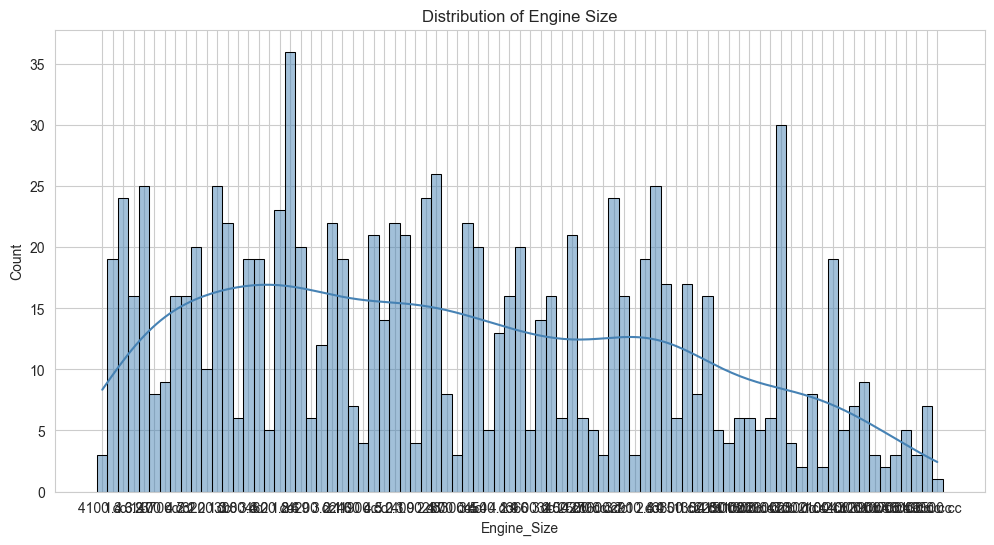

In [158]:
print(f'{df_train['Engine_Size'].describe()} \n')
print(df_train['Engine_Size'].unique())
sns.histplot(df_train['Engine_Size'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.title('Distribution of Engine Size')

Fuel_Type analysis


In [159]:
print(f'{df_train['Fuel_Type'].describe()} \n')
print(df_train['Fuel_Type'].unique())

count       1280
unique        12
top       Diesel
freq         298
Name: Fuel_Type, dtype: object 

<StringArray>
[  'Petrol',   'Diesel',   'Hybrid', 'Electric', 'ELECTRIC',   'DIESEL',
   'diesel',   'hybrid',   'HYBRID',   'PETROL', 'electric',   'petrol']
Length: 12, dtype: str


Transmission analysis

count          1280
unique            2
top       Automatic
freq            661
Name: Transmission, dtype: object 



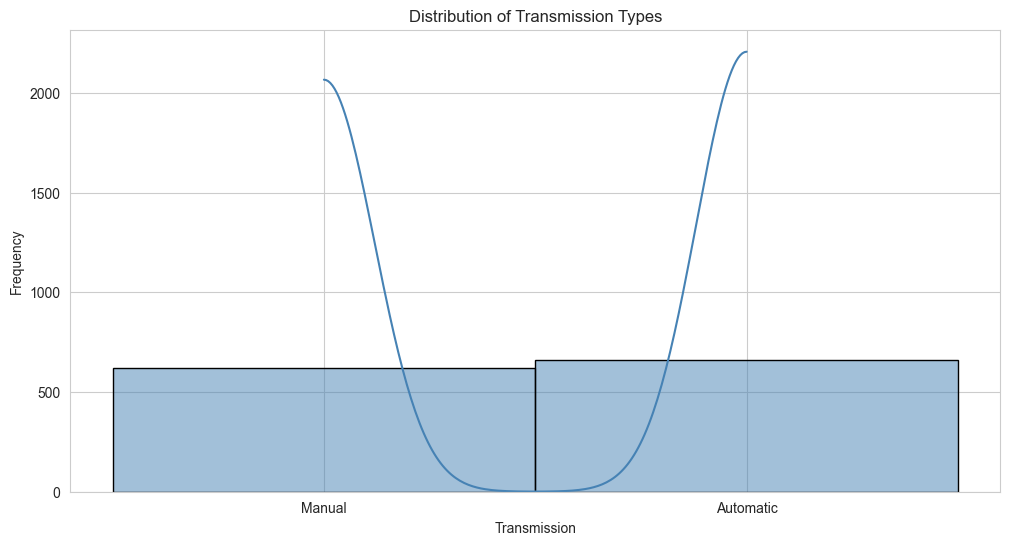

Transmission
Automatic    661
Manual       619
Name: count, dtype: int64 



In [160]:
print(f'{df_train["Transmission"].describe()} \n')


sns.histplot(df_train['Transmission'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.title('Distribution of Transmission Types')
plt.xlabel('Transmission')
plt.ylabel('Frequency')
plt.show()

print(f'{df_train["Transmission"].value_counts()} \n')

PreFixing 

In [161]:
# change wrong values in model_year for NaN
df_train['Model_Year'] = df_train['Model_Year'].mask(df_train["Model_Year"]<1900, np.nan)
df_test['Model_Year'] = df_test['Model_Year'].mask(df_test["Model_Year"]<1900, np.nan)
print(df_train['Model_Year'].unique())


[  nan 2017. 2015. 2012. 2022. 2013. 2008. 2016. 2014. 2023. 2018. 2011.
 2021. 2020. 2006. 2005. 2019. 2010. 2007. 2009.]


In [162]:
# change values higher than 800000 in mileage for NaN
df_train['Mileage'] = df_train['Mileage'].mask(df_train["Mileage"]>800000, np.nan)
df_test['Mileage'] = df_test['Mileage'].mask(df_test["Mileage"]>800000, np.nan)
print(df_train['Mileage'].describe())

count       992.000000
mean     101216.072581
std       56558.223449
min        5036.000000
25%       52708.500000
50%      101566.000000
75%      148326.750000
max      199904.000000
Name: Mileage, dtype: float64


In [163]:
# change values higher than 1500 in horsepower for NaN
df_train['Horsepower'] = df_train['Horsepower'].mask(df_train["Horsepower"]>1500, np.nan)
df_test['Horsepower'] = df_test['Horsepower'].mask(df_test["Horsepower"]>1500, np.nan)
print(df_train['Horsepower'].describe())

count    996.000000
mean     233.088353
std       95.495240
min       70.000000
25%      151.750000
50%      233.500000
75%      316.250000
max      399.000000
Name: Horsepower, dtype: float64


In [164]:
# erase rows with price lower or equal to 0 as there are only a few of them and they are likely to be errors in data collection
df_train = df_train[df_train['Price'] > 0].reset_index(drop=True)
df_test = df_test[df_test['Price'] > 0].reset_index(drop=True)
print(df_train['Price'].value_counts())

Price
61395.45    1
49188.90    1
47151.75    1
48857.70    1
51072.50    1
           ..
32714.75    1
33014.60    1
50202.20    1
60679.50    1
44325.45    1
Name: count, Length: 1217, dtype: int64


In [165]:
# Standarize engine size 
df_train["Engine_Size"]= df_train["Engine_Size"].astype(str).str.replace(' cc', '', case=False)
df_train["Engine_Size"]= pd.to_numeric(df_train["Engine_Size"], errors='coerce')
df_train["Engine_Size"]= df_train["Engine_Size"].mask(df_train["Engine_Size"]>10, df_train["Engine_Size"]/1000)
print(df_train["Engine_Size"].unique())
print(df_train["Engine_Size"].describe())

df_test["Engine_Size"]= df_test["Engine_Size"].astype(str).str.replace(' cc', '', case=False)
df_test["Engine_Size"]= pd.to_numeric(df_test["Engine_Size"], errors='coerce')
df_test["Engine_Size"]= df_test["Engine_Size"].mask(df_test["Engine_Size"]>10, df_test["Engine_Size"]/1000)


[4.1 1.4 3.6 nan 3.9 2.7 3.7 4.7 2.2 1.2 3.2 1.3 3.8 3.  3.4 4.6 1.8 2.6
 4.9 4.2 2.1 1.6 2.4 1.9 4.3 5.  2.3 4.  1.7 3.3 3.5 4.4 4.5 2.9 3.1 2.5
 1.1 2.8 1.5 4.8 2.  1. ]
count    969.000000
mean       2.972859
std        1.144090
min        1.000000
25%        2.000000
50%        3.000000
75%        3.900000
max        5.000000
Name: Engine_Size, dtype: float64


In [166]:
#standarize fuel type values
df_train['Fuel_Type'] = df_train['Fuel_Type'].str.lower().str.strip()
df_test['Fuel_Type'] = df_test['Fuel_Type'].str.lower().str.strip()
print(df_train['Fuel_Type'].unique())


<StringArray>
['petrol', 'diesel', 'hybrid', 'electric']
Length: 4, dtype: str


In [167]:
# change tesla's Fuel_type to electric as all tesla cars are electric 
df_train.loc[df_train['Brand'] == 'Tesla', 'Fuel_Type'] = 'electric'
df_test.loc[df_test['Brand'] == 'Tesla', 'Fuel_Type'] = 'electric'
print(df_train[df_train['Brand']== "Tesla"])


      Car_ID  Brand  Model_Year  Engine_Size Fuel_Type Transmission   Mileage  \
2       1587  Tesla      2017.0          3.6  electric    Automatic  132385.0   
5       1140  Tesla      2017.0          3.9  electric    Automatic  186762.0   
10      1895  Tesla      2022.0          2.2  electric    Automatic  115379.0   
22      1003  Tesla      2011.0          2.6  electric       Manual  177704.0   
26      1059  Tesla      2021.0          4.9  electric       Manual       NaN   
...      ...    ...         ...          ...       ...          ...       ...   
1173     881  Tesla         NaN          2.6  electric    Automatic  199904.0   
1197      84  Tesla         NaN          2.6  electric       Manual    7402.0   
1210    1009  Tesla         NaN          4.6  electric       Manual   19439.0   
1211     774  Tesla      2021.0          1.0  electric    Automatic       NaN   
1213     660  Tesla         NaN          NaN  electric       Manual  162088.0   

      Doors  Owner_Count  H

Pipeline 

In [168]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import importlib.util
import joblib
import os

In [169]:
feature_columns = ['Model_Year', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Brand', 'Fuel_Type', 'Transmission', 'Engine_Size']

target_column = "Price"



numerical_features =['Model_Year', 'Mileage', 'Engine_Size','Doors', 'Owner_Count', 'Owner_Count','Horsepower']
horsepower_feature = ['Horsepower','Brand']
categorical_features = ['Brand', 'Transmission', 'Fuel_Type']



X_train = df_train[feature_columns]
y_train = df_train[target_column]

X_test = df_test[feature_columns]
y_test = df_test[target_column]
X_train_copy=X_train.copy()
y_train_copy=y_train.copy()
print(X_test.shape, y_test.shape, X_train.shape, y_train.shape)

(306, 9) (306,) (1217, 9) (1217,)


In [170]:
# custom imputer for horsepower feature 
from sklearn.base import BaseEstimator, TransformerMixin

class HorsepowerImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col='Brand', target_col='Horsepower'):
        self.group_col = group_col
        self.target_col = target_col
        self.median_map = None

    def fit(self, X, y=None):
        self.median_map = X.groupby(self.group_col)[self.target_col].median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.target_col] = X[self.target_col].fillna(X[self.group_col].map(self.median_map))
        
        return X[[self.target_col]]
    
    def set_output(self, transform = "pandas"):
        return self

In [171]:
horsepower_pipeline = Pipeline([
    ("imputer", HorsepowerImputer(group_col='Brand', target_col='Horsepower')),
    ("scaler", StandardScaler()),
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

other_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("scaler", MinMaxScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler",OneHotEncoder(handle_unknown="ignore", sparse_output=False)),

])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features[0:3]),
    ("horsepower", horsepower_pipeline, horsepower_feature),
    ("other_numeric", other_numeric_pipeline, numerical_features[3:6]),
    ("categorical", categorical_pipeline, categorical_features),
])


import joblib

joblib.dump(preprocessor, 'pipeline.pkl')


preprocessor.set_output(transform="pandas")

preprocessor_fit= preprocessor.fit(X_train_copy)
preprocessor_fit 


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('horsepower', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [172]:
x_train_procesed = preprocessor_fit.transform(X_train_copy)

type(x_train_procesed)

x_train_procesed.head()

,numeric__Model_Year,numeric__Mileage,numeric__Engine_Size,horsepower__Horsepower,other_numeric__Doors,other_numeric__Owner_Count,other_numeric__Owner_Count,categorical__Brand_BMW,categorical__Brand_Ford,categorical__Brand_Honda,categorical__Brand_Hyundai,categorical__Brand_Tesla,categorical__Brand_Toyota,categorical__Transmission_Automatic,categorical__Transmission_Manual,categorical__Fuel_Type_diesel,categorical__Fuel_Type_electric,categorical__Fuel_Type_hybrid,categorical__Fuel_Type_petrol
0,0.0,0.599587,0.785714,1.450955,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,-0.016609,-1.142857,1.925444,1.0,0.666667,0.666667,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.6,0.431535,0.428571,0.110522,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.000000,0.000000,-0.933354,0.0,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.6,-0.991616,0.000000,-0.043687,1.0,0.333333,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
